# Atividade Prática - Unidade 03

### Preparação e gravação dos dados

Este trecho inicia a análise, cria ou abre um banco SQLite, define a tabela de vendas e grava os registros de exemplo. A conexão mantêm os dados disponéveis para consulta.

In [7]:
# ==============================================================================
# PROJETO: ANÁLISE DE VENDAS DE VAREJO
# AUTOR: LUÍS HENRIQUE DE SOUZA
# AMBIENTE: GOOGLE COLAB / PYTHON 3
# ==============================================================================

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo visual dos gráficos
sns.set_theme(style="whitegrid")


# ------------------------------------------------------------------------------
# PASSO 1: CONECTAR AO BANCO DE DADOS E INSERIR DADOS
# ------------------------------------------------------------------------------

# Conectar/Criar banco SQLite
conexao = sqlite3.connect('dados_vendas.db')
cursor = conexao.cursor()

# Limpar tabela caso já exista para evitar duplicidade em reexecuções
cursor.execute('DROP TABLE IF EXISTS vendas1')

### Estrutura e carga do banco

Aqui a tabela de vendas é criada e preenchida com registros fictícios de 2023. A versão ampliada usa inserção parametrizada (`executemany`) para gravar vários registros.

In [8]:
# Criar a tabela vendas1
cursor.execute('''
CREATE TABLE vendas1 (
    id_venda INTEGER PRIMARY KEY AUTOINCREMENT,
    data_venda DATE,
    produto TEXT,
    categoria TEXT,
    valor_venda REAL
)
''')

# Inserir os registros
query_insercao = '''
INSERT INTO vendas1 (data_venda, produto, categoria, valor_venda) VALUES
('2023-01-01', 'Produto A', 'Eletrônicos', 1500.00),
('2023-01-05', 'Produto B', 'Roupas', 350.00),
('2023-02-10', 'Produto C', 'Eletrônicos', 1200.00),
('2023-03-15', 'Produto D', 'Livros', 200.00),
('2023-03-20', 'Produto E', 'Eletrônicos', 800.00),
('2023-04-02', 'Produto F', 'Roupas', 400.00),
('2023-05-05', 'Produto G', 'Livros', 150.00),
('2023-06-10', 'Produto H', 'Eletrônicos', 1000.00),
('2023-07-20', 'Produto I', 'Roupas', 600.00),
('2023-08-25', 'Produto J', 'Eletrônicos', 700.00),
('2023-09-30', 'Produto K', 'Livros', 300.00),
('2023-10-05', 'Produto L', 'Roupas', 450.00),
('2023-11-15', 'Produto M', 'Eletrônicos', 900.00),
('2023-12-20', 'Produto N', 'Livros', 250.00);
'''

# executa os scripts de banco de dados e confirma (commit)
cursor.execute(query_insercao)
conexao.commit()

### Leitura e preparação dos dados

Este bloco carrega os registros em um DataFrame do Pandas, converte datas para o tipo apropriado e cria campos auxiliares para análises temporais. Também inspeciona os dados e verifica valores ausentes.

In [9]:
# ------------------------------------------------------------------------------
# PASSO 2: CARREGAR E PREPARAR OS DADOS COM PANDAS
# ------------------------------------------------------------------------------

df_vendas = pd.read_sql_query("SELECT * FROM vendas1", conexao)

# Converter tipo da coluna para datetime
df_vendas['data_venda'] = pd.to_datetime(df_vendas['data_venda'])

# Criar coluna de Mês/Ano para análise temporal
df_vendas['mes_ano'] = df_vendas['data_venda'].dt.to_period('M')

print("--- Visão Geral do Dataset ---")
print(df_vendas.head())
print("\n--- Informações dos Tipos de Dados ---")
print(df_vendas.info())

--- Visão Geral do Dataset ---
   id_venda data_venda    produto    categoria  valor_venda  mes_ano
0         1 2023-01-01  Produto A  Eletrônicos       1500.0  2023-01
1         2 2023-01-05  Produto B       Roupas        350.0  2023-01
2         3 2023-02-10  Produto C  Eletrônicos       1200.0  2023-02
3         4 2023-03-15  Produto D       Livros        200.0  2023-03
4         5 2023-03-20  Produto E  Eletrônicos        800.0  2023-03

--- Informações dos Tipos de Dados ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_venda     14 non-null     int64         
 1   data_venda   14 non-null     datetime64[ns]
 2   produto      14 non-null     object        
 3   categoria    14 non-null     object        
 4   valor_venda  14 non-null     float64       
 5   mes_ano      14 non-null     period[M]     
dtypes: datetime64[ns

### Célculo das métricas

As operações agrupam as vendas por categoria, mês, trimestre ou produto para calcular faturamento e outras medidas. A versão ampliada acrescenta participação percentual, desvio padrão e ranking de produtos.

In [18]:
# ------------------------------------------------------------------------------
# PASSO 3: ANÁLISE DOS DADOS
# ------------------------------------------------------------------------------

# Faturamento Total
faturamento_total = df_vendas['valor_venda'].sum()

# Resumo por Categoria
resumo_categoria = df_vendas.groupby('categoria')['valor_venda'].agg(
    faturamento_total='sum',
    ticket_medio='mean',
    quantidade_vendas='count'
).reset_index().sort_values(by='faturamento_total', ascending=False)

# média de vendas mensal
media_venda_mensal = df_vendas.groupby('mes_ano')['valor_venda'].sum().mean()

media_venda_por_produto_mensal = df_vendas.groupby(['mes_ano', 'produto'])['valor_venda'].sum().groupby('mes_ano').mean()

print("--- Métricas Estatísticas ---")
print(f"\nMédia de Venda Mensal: R$ {media_venda_mensal:,.2f}")
print("\n--- Média de Venda por Produto Mensalmente ---")
print(media_venda_por_produto_mensal)
print(f"\nFaturamento Total do Ano: R$ {faturamento_total:,.2f}")
print("\n--- Desempenho por Categoria ---")
print(resumo_categoria)

--- Métricas Estatísticas ---

Média de Venda Mensal: R$ 733.33

--- Média de Venda por Produto Mensalmente ---
mes_ano
2023-01     925.0
2023-02    1200.0
2023-03     500.0
2023-04     400.0
2023-05     150.0
2023-06    1000.0
2023-07     600.0
2023-08     700.0
2023-09     300.0
2023-10     450.0
2023-11     900.0
2023-12     250.0
Freq: M, Name: valor_venda, dtype: float64

Faturamento Total do Ano: R$ 8,800.00

--- Desempenho por Categoria ---
     categoria  faturamento_total  ticket_medio  quantidade_vendas
0  Eletrônicos             6100.0   1016.666667                  6
2       Roupas             1800.0    450.000000                  4
1       Livros              900.0    225.000000                  4


### Célculo das métricas

As operações agrupam as vendas por categoria, mês, trimestre ou produto para calcular faturamento e outras medidas. A versão ampliada acrescenta participação percentual, desvio padrão e ranking de produtos.

In [ ]:
# ------------------------------------------------------------------------------
# PASSO 4: VISUALIZAÇÃO DOS DADOS
# ------------------------------------------------------------------------------

# Gráfico 1: Faturamento por Categoria (Gráfico de Barras)
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=resumo_categoria,
    x='categoria',
    y='faturamento_total',
    hue='quantidade_vendas',
    hue_order=resumo_categoria['quantidade_vendas'].sort_values(ascending=False),
    legend=False
)

plt.title('Faturamento Total por Categoria (2023)', fontsize=14, fontweight='bold')
plt.xlabel('Categoria de Produtos', fontsize=11)
plt.ylabel('Faturamento (R$)', fontsize=11)

# Adicionar rótulos com valores em cima das barras
for p in ax.patches:
    ax.annotate(f'R$ {p.get_height():,.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.show()

# Gráfico 2: Evolução das Vendas ao Longo do Tempo (Gráfico de Linhas)
vendas_temporais = df_vendas.groupby('data_venda')['valor_venda'].sum().reset_index()

plt.figure(figsize=(10, 4.5))
sns.lineplot(data=vendas_temporais, x='data_venda', y='valor_venda', marker='o', color='darkblue')
plt.title('Evolução das Vendas no Decorrer de 2023', fontsize=14, fontweight='bold')
plt.xlabel('Data da Venda', fontsize=11)
plt.ylabel('Valor da Venda (R$)', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Fechar conexão com o banco
conexao.close()

Esta célula está reservada para anotações ou execução complementar.

Esta célula está reservada para anotações ou execução complementar.

Esta célula está reservada para anotações ou execução complementar.

### Preparação e gravação dos dados

Este trecho inicia a análise, cria ou abre um banco SQLite, define a tabela de vendas e grava os registros de exemplo. A conexão mantêm os dados disponéveis para consulta.

In [25]:
# ==============================================================================
# PROJETO: ANÁLISE DE VENDAS DE VAREJO
# AUTOR: LUÍS HENRIQUE DE SOUZA
# AMBIENTE: GOOGLE COLAB / PYTHON 3
# ==============================================================================

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo visual dos gráficos
sns.set_theme(style="whitegrid")


# ------------------------------------------------------------------------------
# PASSO 1: CONECTAR AO BANCO DE DADOS E INSERIR DADOS
# ------------------------------------------------------------------------------

# Conectar/Criar banco SQLite usando context manager (garante commit/rollback automático)
with sqlite3.connect('dados_vendas.db') as conexao:
    cursor = conexao.cursor()

    # Limpar tabela caso já exista, para evitar duplicidade em reexecuções
    cursor.execute('DROP TABLE IF EXISTS vendas1')

    # Criar a tabela vendas1
    cursor.execute('''
        CREATE TABLE vendas1 (
            id_venda INTEGER PRIMARY KEY AUTOINCREMENT,
            data_venda DATE,
            produto TEXT,
            categoria TEXT,
            valor_venda REAL
        )
    ''')

    # Dados a inserir (lista de tuplas) -> inserção parametrizada com executemany
    registros_vendas = [
        ('2023-01-01', 'Produto A', 'Eletrônicos', 1500.00),
        ('2023-01-05', 'Produto B', 'Roupas', 350.00),
        ('2023-02-10', 'Produto C', 'Eletrônicos', 1200.00),
        ('2023-03-15', 'Produto D', 'Livros', 200.00),
        ('2023-03-20', 'Produto E', 'Eletrônicos', 800.00),
        ('2023-04-02', 'Produto F', 'Roupas', 400.00),
        ('2023-05-05', 'Produto G', 'Livros', 150.00),
        ('2023-06-10', 'Produto H', 'Eletrônicos', 1000.00),
        ('2023-07-20', 'Produto I', 'Roupas', 600.00),
        ('2023-08-25', 'Produto J', 'Eletrônicos', 700.00),
        ('2023-09-30', 'Produto K', 'Livros', 300.00),
        ('2023-10-05', 'Produto L', 'Roupas', 450.00),
        ('2023-11-15', 'Produto M', 'Eletrônicos', 900.00),
        ('2023-12-20', 'Produto N', 'Livros', 250.00),
    ]

    cursor.executemany('''
        INSERT INTO vendas1 (data_venda, produto, categoria, valor_venda)
        VALUES (?, ?, ?, ?)
    ''', registros_vendas)

    conexao.commit()


    # ------------------------------------------------------------------------------
    # PASSO 2: CARREGAR E PREPARAR OS DADOS COM PANDAS
    # ------------------------------------------------------------------------------

    df_vendas = pd.read_sql_query("SELECT * FROM vendas1", conexao)

# Converter tipo da coluna para datetime
df_vendas['data_venda'] = pd.to_datetime(df_vendas['data_venda'])

# Criar colunas auxiliares para análise temporal
df_vendas['mes_ano'] = df_vendas['data_venda'].dt.to_period('M')
df_vendas['trimestre'] = df_vendas['data_venda'].dt.quarter

# Checagem de qualidade dos dados (boa prática antes de qualquer análise)
print("--- Checagem de Valores Nulos ---")
print(df_vendas.isnull().sum())

print("\n--- Visão Geral do Dataset ---")
print(df_vendas.head())

print("\n--- Informações dos Tipos de Dados ---")
print(df_vendas.info())

--- Checagem de Valores Nulos ---
id_venda       0
data_venda     0
produto        0
categoria      0
valor_venda    0
mes_ano        0
trimestre      0
dtype: int64

--- Visão Geral do Dataset ---
   id_venda data_venda    produto    categoria  valor_venda  mes_ano  \
0         1 2023-01-01  Produto A  Eletrônicos       1500.0  2023-01   
1         2 2023-01-05  Produto B       Roupas        350.0  2023-01   
2         3 2023-02-10  Produto C  Eletrônicos       1200.0  2023-02   
3         4 2023-03-15  Produto D       Livros        200.0  2023-03   
4         5 2023-03-20  Produto E  Eletrônicos        800.0  2023-03   

   trimestre  
0          1  
1          1  
2          1  
3          1  
4          1  

--- Informações dos Tipos de Dados ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_venda     14 non-null     int64

### Célculo das métricas

As operações agrupam as vendas por categoria, mês, trimestre ou produto para calcular faturamento e outras medidas. A versão ampliada acrescenta participação percentual, desvio padrão e ranking de produtos.

In [28]:
# ------------------------------------------------------------------------------
# PASSO 3: ANÁLISE DOS DADOS
# ------------------------------------------------------------------------------

# Faturamento Total
faturamento_total = df_vendas['valor_venda'].sum()

# Resumo por Categoria (faturamento, ticket médio, quantidade, desvio padrão)
resumo_categoria = df_vendas.groupby('categoria')['valor_venda'].agg(
    faturamento_total='sum',
    ticket_medio='mean',
    quantidade_vendas='count',
    desvio_padrao='std'
).reset_index().sort_values(by='faturamento_total', ascending=False)

# Participação percentual de cada categoria no faturamento total
resumo_categoria['participacao_pct'] = (
    resumo_categoria['faturamento_total'] / faturamento_total * 100
).round(1)

# Média de venda mensal (faturamento médio por mês)
media_venda_mensal = df_vendas.groupby('mes_ano')['valor_venda'].sum().mean()

# Média de venda por produto, mensalmente
media_venda_por_produto_mensal = (
    df_vendas.groupby(['mes_ano', 'produto'])['valor_venda'].sum()
    .groupby('mes_ano').mean()
)

# Faturamento por trimestre (visão de sazonalidade)
resumo_trimestre = df_vendas.groupby('trimestre')['valor_venda'].sum()

# Ranking de produtos por faturamento
ranking_produtos = (
    df_vendas.groupby('produto')['valor_venda'].sum()
    .sort_values(ascending=False)
)

print("\n--- Métricas Estatísticas ---")
print(f"Faturamento Total do Ano: R$ {faturamento_total:,.2f}")
print(f"Média de Venda Mensal: R$ {media_venda_mensal:,.2f}")

print("\n--- Desempenho por Categoria ---")
print(resumo_categoria)

print("\n--- Faturamento por Trimestre ---")
print(resumo_trimestre)

print("\n--- Ranking de Produtos por Faturamento ---")
print(ranking_produtos)

print("\n--- Média de Venda por Produto Mensalmente ---")
print(media_venda_por_produto_mensal)


--- Métricas Estatísticas ---
Faturamento Total do Ano: R$ 8,800.00
Média de Venda Mensal: R$ 733.33

--- Desempenho por Categoria ---
     categoria  faturamento_total  ticket_medio  quantidade_vendas  \
0  Eletrônicos             6100.0   1016.666667                  6   
2       Roupas             1800.0    450.000000                  4   
1       Livros              900.0    225.000000                  4   

   desvio_padrao  participacao_pct  
0     292.688686              69.3  
2     108.012345              20.5  
1      64.549722              10.2  

--- Faturamento por Trimestre ---
trimestre
1    4050.0
2    1550.0
3    1600.0
4    1600.0
Name: valor_venda, dtype: float64

--- Ranking de Produtos por Faturamento ---
produto
Produto A    1500.0
Produto C    1200.0
Produto H    1000.0
Produto M     900.0
Produto E     800.0
Produto J     700.0
Produto I     600.0
Produto L     450.0
Produto F     400.0
Produto B     350.0
Produto K     300.0
Produto N     250.0
Produto D     2

### Célculo das métricas

As operações agrupam as vendas por categoria, mês, trimestre ou produto para calcular faturamento e outras medidas. A versão ampliada acrescenta participação percentual, desvio padrão e ranking de produtos.

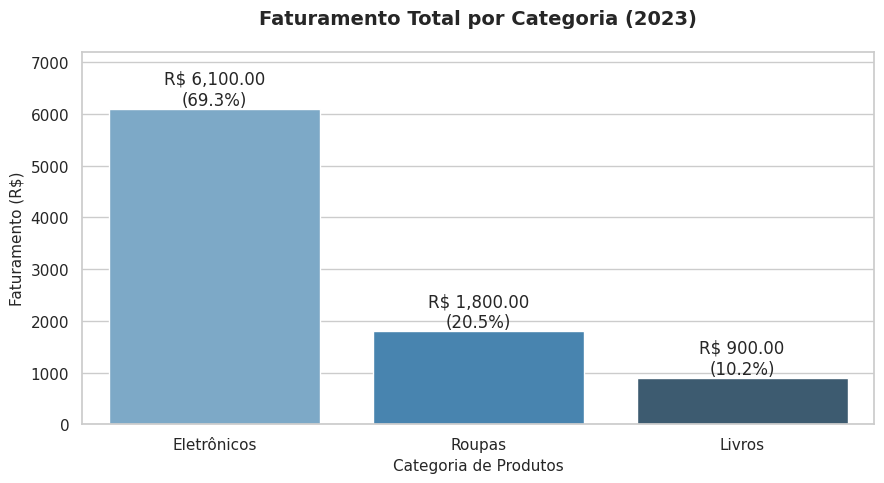

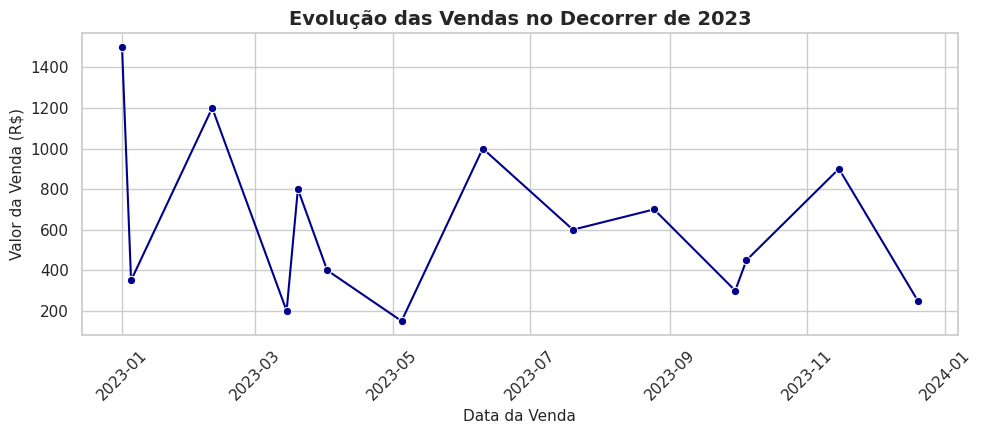

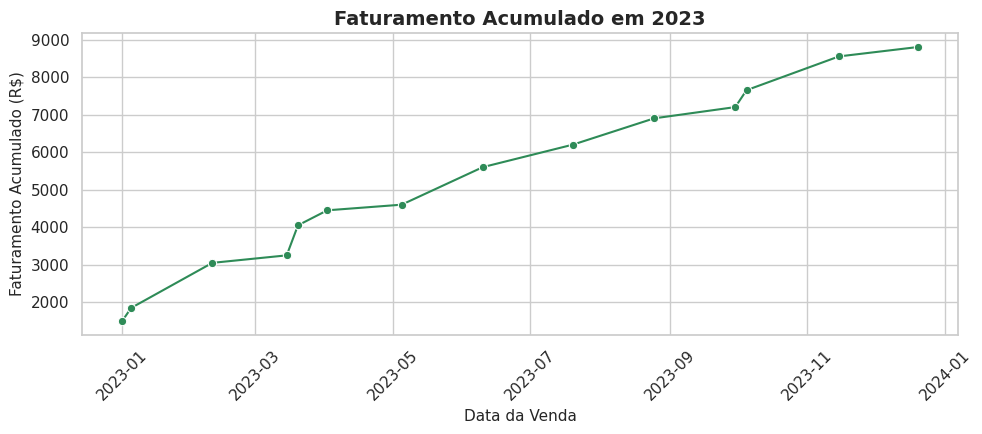

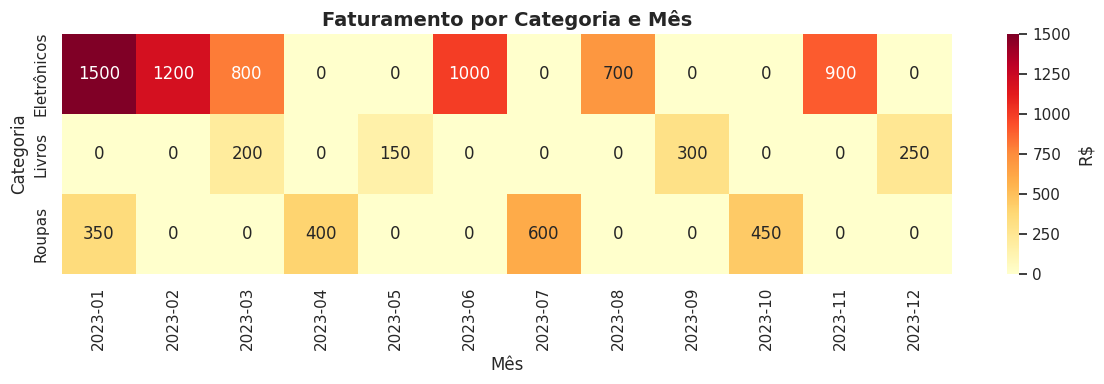

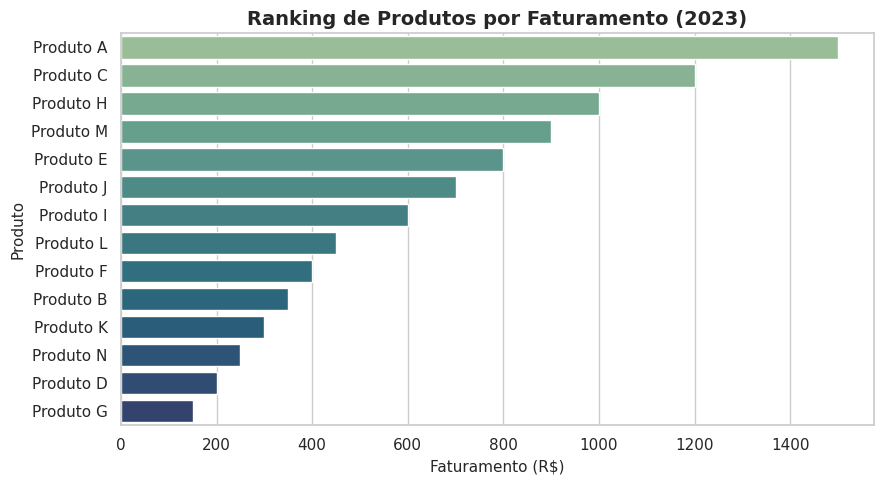

In [27]:
# ------------------------------------------------------------------------------
# PASSO 4: VISUALIZAÇÃO DOS DADOS
# ------------------------------------------------------------------------------

# Gráfico 1: Faturamento por Categoria (Gráfico de Barras)
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=resumo_categoria,
    x='categoria',
    y='faturamento_total',
    hue='categoria',
    palette='Blues_d',
    legend=False
)

plt.title('Faturamento Total por Categoria (2023)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Categoria de Produtos', fontsize=11)
plt.ylabel('Faturamento (R$)', fontsize=11)
plt.ylim(0, resumo_categoria['faturamento_total'].max() * 1.18)

# Adicionar rótulos com valores e participação percentual em cima das barras
for p, pct in zip(ax.patches, resumo_categoria['participacao_pct']):
    ax.annotate(f'R$ {p.get_height():,.2f}\n({pct}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 14), textcoords='offset points')

plt.tight_layout()
plt.savefig('grafico_1_faturamento_categoria.png', dpi=150)
plt.show()

# Gráfico 2: Evolução das Vendas ao Longo do Tempo (Gráfico de Linhas)
vendas_temporais = df_vendas.groupby('data_venda')['valor_venda'].sum().reset_index()
vendas_temporais['acumulado'] = vendas_temporais['valor_venda'].cumsum()

plt.figure(figsize=(10, 4.5))
sns.lineplot(data=vendas_temporais, x='data_venda', y='valor_venda', marker='o', color='darkblue')
plt.title('Evolução das Vendas no Decorrer de 2023', fontsize=14, fontweight='bold')
plt.xlabel('Data da Venda', fontsize=11)
plt.ylabel('Valor da Venda (R$)', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('grafico_2_evolucao_vendas.png', dpi=150)
plt.show()

# Gráfico 3: Faturamento Acumulado no Ano (mostra ritmo de crescimento)
plt.figure(figsize=(10, 4.5))
sns.lineplot(data=vendas_temporais, x='data_venda', y='acumulado', marker='o', color='seagreen')
plt.title('Faturamento Acumulado em 2023', fontsize=14, fontweight='bold')
plt.xlabel('Data da Venda', fontsize=11)
plt.ylabel('Faturamento Acumulado (R$)', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('grafico_3_faturamento_acumulado.png', dpi=150)
plt.show()

# Gráfico 4: Heatmap Categoria x Mês (identifica padrões sazonais)
pivot_cat_mes = df_vendas.pivot_table(
    index='categoria', columns='mes_ano', values='valor_venda', aggfunc='sum', fill_value=0
)

plt.figure(figsize=(12, 4))
sns.heatmap(pivot_cat_mes, annot=True, fmt=".0f", cmap="YlOrRd", cbar_kws={'label': 'R$'})
plt.title('Faturamento por Categoria e Mês', fontsize=14, fontweight='bold')
plt.xlabel('Mês')
plt.ylabel('Categoria')
plt.tight_layout()
plt.savefig('grafico_4_heatmap_categoria_mes.png', dpi=150)
plt.show()

# Gráfico 5: Top produtos por faturamento
plt.figure(figsize=(9, 5))
ranking_df = ranking_produtos.reset_index()
ranking_df.columns = ['produto', 'valor_venda']
sns.barplot(data=ranking_df, x='valor_venda', y='produto', hue='produto',
            palette='crest', legend=False)
plt.title('Ranking de Produtos por Faturamento (2023)', fontsize=14, fontweight='bold')
plt.xlabel('Faturamento (R$)', fontsize=11)
plt.ylabel('Produto', fontsize=11)
plt.tight_layout()
plt.savefig('grafico_5_ranking_produtos.png', dpi=150)
plt.show()
